<div style="text-align: center; padding: 35px; background-color: #f5f7fa; border-radius: 16px; box-shadow: 0px 6px 14px rgba(0,0,0,0.1); margin-bottom: 30px;">

  <h1 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:40px; margin-bottom:10px;">
    Functional Question 2: NR1 Ligandability Analysis
  </h1>

  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:0;">
   Free-energy (ΔG) analysis Analysis of NR1
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:16px; margin-top:20px;">
    Author: <b>Vallari Eastman</b> <br>
    Date: <b>Nov 2025</b>
  </p>
</div>


<div style="background-color:#f8f9fb; padding:20px; border-radius:10px;">
    <div style="background-color:#f8f9fb; padding:20px; border-radius:10px;">
    <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Formal Functional Question 2:
  </h2>
<p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
        How can free-energy (ΔG) analysis be used to evaluate the energetic plausibility of antibody epitopes and identify conformational states of NR1 that are ligandable?
 </p>
</div>

<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Introduction:
  </h2>
<p style="text-indent:30px; color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px; line-height:1.6;">
    Known epitopes tend to lie in low energetic zones. Proteins often have “frustration landscapes” (energy maps) where surface-exposed, energetically neutral patches serve as natural ligand-binding sites (including for antibodies).
Epitopes generally avoid residues with high local energetic frustration because antibodies cannot bind tightly to regions that are structurally strained or mechanically load-bearing.
<br><br>
Epitopes almost always occupy residues with low ΔΔG sensitivity. Mutation scanning studies (alanine scans, saturation mutagenesis) show that epitope residues are typically tolerant to mutation, meaning their ΔΔG of folding is small or near zero. This is because antibody binding cannot rely on residues that are crucial for the protein’s structural integrity. Those residues simply cannot move or deform to accommodate an antibody. 
    <br><br>
    Tajima et al. (2022) identifies several epitope locations on the NR1 amino-terminal domain (ATD). Mutation of E101 removes antibody binding, showing that this residue is part of the epitope (Tajima et al., 2022). Changes to the N368 glycosylation site also reduce antibody effects, placing another part of the epitope near this loop (Tajima et al., 2022). Structural modeling shows that these regions form a contiguous surface on the upper ATD that antibodies recognize (Tajima et al., 2022). Overall, the mapped epitope includes the E101 loop, the N368-associated loop, and nearby exposed ATD surface.
</p>

<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Methods:
  </h2>
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:0;">
    <b> Thermal Stability Prediction Work Flow</b>
  </h3> 
   <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
       0. Previously in VL07, Cloned pretrained protein sequence embedding repo and download its pretrained models. <br>
       1. Generate single point mutations based on epitope location from Tajima et al., 2022<br>
       2. Load mutations list into VL02 and generate ΔΔG (ddG) values for single-point mutants from FireProt. <br>
       3. Load ddG values into current notebook and group by epitope for analysis<br>
       6. Evaluate using grouped cross-validation across proteins and summarize with Pearson R.<br><br>
       Assumptions / limitations:<br>
       a. Each ddG measurement is high quality and comparable across proteins (not always true experimentally).<br>
       b. Single point mutations behave independently (ignores epistasis and environment).<br>
       c. ddG is treated as a purely sequence-driven function (but stability is super contextual — solvent, pH, folding helpers, etc.).</p>
</div>

In [8]:
# Import FASTA (PDB 7E8U)
from pathlib import Path

fasta_path = Path("7EU8A&C.txt")

with open(fasta_path) as f:
    lines = [line.strip() for line in f if line.strip()]

# if it's just sequence lines, concatenate them
nr1_seq = "".join(line for line in lines if not line.startswith(">"))

Generate NR1 mutants around epitopes (like VL07 mutant reconstruction step)

Take the NR1 sequence and create in silico mutants for residues in predicted epitopes (e.g., alanine scan, charge swaps).

In [7]:
# Define Epitopes on Tajima et al., 2022

#align sequence to the Tajima sequence
print(len(nr1_seq))
print("Residue 101:", nr1_seq[100])   # should be 'E'
print("Residue 368:", nr1_seq[367])   # should be 'N'

E101_like_center_1based = 80
N368_center_1based = 368

epitopes_1based = {
    "E101_like_loop": list(range(E101_like_center_1based - 5, E101_like_center_1based + 6)),  # 75–85
    "N368_loop":      list(range(N368_center_1based      - 5, N368_center_1based      + 6)),  # 363–373
}

# convert to 0-based for sequence indexing
epitopes = {
    name: [pos - 1 for pos in positions]
    for name, positions in epitopes_1based.items()
}

epitopes
for name, positions in epitopes.items():
    print(name)
    for pos0 in positions:
        print(pos0+1, nr1_seq[pos0])
    print()

1709
Residue 101: H
Residue 368: N
E101_like_loop
75 A
76 L
77 S
78 V
79 C
80 E
81 D
82 L
83 I
84 S
85 S

N368_loop
363 Q
364 V
365 G
366 I
367 Y
368 N
369 G
370 T
371 H
372 V
373 I



In [9]:
# alanine scan and charge swap

import pandas as pd

def mutate_sequence(seq: str, pos0: int, new_aa: str) -> str:
    seq_list = list(seq)
    seq_list[pos0] = new_aa
    return "".join(seq_list)

# --- Alanine scan ---
alanine_mutants = []

for epitope_name, positions in epitopes.items():
    for pos0 in positions:
        wt_aa = nr1_seq[pos0]
        if wt_aa == "A":
            continue  # already alanine

        mut_seq = mutate_sequence(nr1_seq, pos0, "A")

        alanine_mutants.append({
            "epitope_name": epitope_name,
            "mutation_type": "ALA_scan",
            "pos_index": pos0 + 1,           # 1-based
            "pos_0based": pos0,
            "wt_aa": wt_aa,
            "mut_aa": "A",
            "mutation_label": f"{wt_aa}{pos0+1}A",
            "wt_sequence": nr1_seq,
            "mut_sequence": mut_seq,
        })

ala_df = pd.DataFrame(alanine_mutants)

# --- Charge swaps ---
charge_swaps = {"K": "E", "R": "E", "H": "E", "D": "K", "E": "K"}

def get_charge_swap(wt_aa: str):
    return charge_swaps.get(wt_aa, None)

charge_mutants = []

for epitope_name, positions in epitopes.items():
    for pos0 in positions:
        wt_aa = nr1_seq[pos0]
        mut_aa = get_charge_swap(wt_aa)
        if mut_aa is None:
            continue  # not a charged residue we want to swap

        mut_seq = mutate_sequence(nr1_seq, pos0, mut_aa)

        charge_mutants.append({
            "epitope_name": epitope_name,
            "mutation_type": "charge_swap",
            "pos_index": pos0 + 1,
            "pos_0based": pos0,
            "wt_aa": wt_aa,
            "mut_aa": mut_aa,
            "mutation_label": f"{wt_aa}{pos0+1}{mut_aa}",
            "wt_sequence": nr1_seq,
            "mut_sequence": mut_seq,
        })

charge_df = pd.DataFrame(charge_mutants)

mutants_df = pd.concat([ala_df, charge_df], ignore_index=True)
mutants_df.head()


,epitope_name,mutation_type,pos_index,pos_0based,wt_aa,mut_aa,mutation_label,wt_sequence,mut_sequence
0,E101_like_loop,ALA_scan,76,75,L,A,L76A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...
1,E101_like_loop,ALA_scan,77,76,S,A,S77A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...
2,E101_like_loop,ALA_scan,78,77,V,A,V78A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...
3,E101_like_loop,ALA_scan,79,78,C,A,C79A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...
4,E101_like_loop,ALA_scan,80,79,E,A,E80A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...


In [11]:
# save in conformational states (open and closed)

conformations = [
    {"conformation_id": "ATD_open",   "pdb_id": "7EU8"},
    {"conformation_id": "ATD_closed", "pdb_id": "4KCC"},
]

expanded = []
for conf in conformations:
    for _, row in mutants_df.iterrows():
        r = row.to_dict()
        r["conformation_id"] = conf["conformation_id"]
        r["pdb_id"] = conf["pdb_id"]
        expanded.append(r)

mutants_conf_df = pd.DataFrame(expanded)
mutants_conf_df.to_csv("NR1_E80_N368_epitope_mutants.csv", index=False)

## USE VL07 Notebook to generate ΔG/ΔΔG
I used the VL07 FireProt thermal stability pipeline as a template: reconstruct mutants → encode mutation identity → train an MLP ΔΔG model on FireProt → apply the trained model to NR1 epitope-focused mutants.

In [17]:
import pandas as pd

mutants_df = pd.read_csv("NR1_epitope_mutants_table.csv")
mutants_df.head(10)

,epitope_name,mutation_type,pos_index,pos_0based,wt_aa,mut_aa,mutation_label,wt_sequence,mut_sequence,conformation_id,pdb_id,ddG_pred
0,E101_like_loop,ALA_scan,76,75,L,A,L76A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,1.218763
1,E101_like_loop,ALA_scan,77,76,S,A,S77A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,-0.827675
2,E101_like_loop,ALA_scan,78,77,V,A,V78A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,1.952736
3,E101_like_loop,ALA_scan,79,78,C,A,C79A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,0.099116
4,E101_like_loop,ALA_scan,80,79,E,A,E80A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,-0.027168
5,E101_like_loop,ALA_scan,81,80,D,A,D81A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,1.207688
6,E101_like_loop,ALA_scan,82,81,L,A,L82A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,1.218763
7,E101_like_loop,ALA_scan,83,82,I,A,I83A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,2.748135
8,E101_like_loop,ALA_scan,84,83,S,A,S84A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,-0.827675
9,E101_like_loop,ALA_scan,85,84,S,A,S85A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,-0.827675


In [20]:
# Group by epitope
mutants_by_epitope = mutants_df.groupby("epitope_name")
mutants_by_epitope

In [25]:
for epitope, group in mutants_by_epitope:
    print(f"\n=== {epitope} ===")
    display(group[["mutation_label", "wt_aa", "mut_aa", "pos_index", "ddG_pred"]])


=== E101_like_loop ===


,mutation_label,wt_aa,mut_aa,pos_index,ddG_pred
0,L76A,L,A,76,1.218763
1,S77A,S,A,77,-0.827675
2,V78A,V,A,78,1.952736
3,C79A,C,A,79,0.099116
4,E80A,E,A,80,-0.027168
5,D81A,D,A,81,1.207688
6,L82A,L,A,82,1.218763
7,I83A,I,A,83,2.748135
8,S84A,S,A,84,-0.827675
9,S85A,S,A,85,-0.827675



=== N368_loop ===


,mutation_label,wt_aa,mut_aa,pos_index,ddG_pred
10,Q363A,Q,A,363,-0.278145
11,V364A,V,A,364,1.952736
12,G365A,G,A,365,0.318699
13,I366A,I,A,366,2.748135
14,Y367A,Y,A,367,1.877858
15,N368A,N,A,368,0.798810
16,G369A,G,A,369,0.318699
17,T370A,T,A,370,0.860663
18,H371A,H,A,371,1.567677
19,V372A,V,A,372,1.952736


In [26]:
clean = mutants_df[["epitope_name", "mutation_type", "mutation_label", "wt_aa", "mut_aa", "pos_index", "ddG_pred"]]
display(clean.head(30))

,epitope_name,mutation_type,mutation_label,wt_aa,mut_aa,pos_index,ddG_pred
0,E101_like_loop,ALA_scan,L76A,L,A,76,1.218763
1,E101_like_loop,ALA_scan,S77A,S,A,77,-0.827675
2,E101_like_loop,ALA_scan,V78A,V,A,78,1.952736
3,E101_like_loop,ALA_scan,C79A,C,A,79,0.099116
4,E101_like_loop,ALA_scan,E80A,E,A,80,-0.027168
5,E101_like_loop,ALA_scan,D81A,D,A,81,1.207688
6,E101_like_loop,ALA_scan,L82A,L,A,82,1.218763
7,E101_like_loop,ALA_scan,I83A,I,A,83,2.748135
8,E101_like_loop,ALA_scan,S84A,S,A,84,-0.827675
9,E101_like_loop,ALA_scan,S85A,S,A,85,-0.827675


In [32]:
mutants_df.groupby("epitope_name")["ddG_pred"].describe()

,count,mean,std,min,25%,50%,75%,max
epitope_name,,,,,,,,
E101_like_loop,24.0,0.502658,1.143504,-0.827675,-0.410290,0.233580,1.218763,2.748135
N368_loop,24.0,1.415671,0.970332,-0.278145,0.678782,1.722768,1.995065,2.748135


In [36]:
# Per-residue trend analysis
residue_stats = (
    mutants_df.groupby("pos_index")["ddG_pred"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

residue_stats

,pos_index,mean,std,min,max
0,76,1.218763,0.000000,1.218763,1.218763
1,77,-0.827675,0.000000,-0.827675,-0.827675
2,78,1.952736,0.000000,1.952736,1.952736
3,79,0.099116,0.000000,0.099116,0.099116
4,80,0.170439,0.228177,-0.027168,0.368045
5,81,0.468263,0.853814,-0.271161,1.207688
6,82,1.218763,0.000000,1.218763,1.218763
7,83,2.748135,0.000000,2.748135,2.748135
8,84,-0.827675,0.000000,-0.827675,-0.827675
9,85,-0.827675,0.000000,-0.827675,-0.827675


In [35]:
#Identify strongly destabilizing mutations
destabilizing = mutants_df.sort_values("ddG_pred", ascending=False).head(10)
destabilizing

,epitope_name,mutation_type,pos_index,pos_0based,wt_aa,mut_aa,mutation_label,wt_sequence,mut_sequence,conformation_id,pdb_id,ddG_pred
7,E101_like_loop,ALA_scan,83,82,I,A,I83A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,2.748135
13,N368_loop,ALA_scan,366,365,I,A,I366A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,2.748135
31,E101_like_loop,ALA_scan,83,82,I,A,I83A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_closed,4KCC,2.748135
20,N368_loop,ALA_scan,373,372,I,A,I373A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,2.748135
37,N368_loop,ALA_scan,366,365,I,A,I366A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_closed,4KCC,2.748135
44,N368_loop,ALA_scan,373,372,I,A,I373A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_closed,4KCC,2.748135
47,N368_loop,charge_swap,371,370,H,E,H371E,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_closed,4KCC,2.122052
23,N368_loop,charge_swap,371,370,H,E,H371E,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,2.122052
19,N368_loop,ALA_scan,372,371,V,A,V372A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_open,7EU8,1.952736
26,E101_like_loop,ALA_scan,78,77,V,A,V78A,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,MSTMRLLTLALLFSCSVARAACDPKIVNIGAVLSTRKHEQMFREAV...,ATD_closed,4KCC,1.952736


In [37]:
# Compare epitopes statistically
epitope_means = mutants_df.groupby("epitope_name")["ddG_pred"].mean()
epitope_means

epitope_name
E101_like_loop    0.502658
N368_loop         1.415671
Name: ddG_pred, dtype: float64

In [38]:
from scipy.stats import ttest_ind

e80_vals = mutants_df[mutants_df["epitope_name"] == "E101_like_loop"]["ddG_pred"]
n368_vals = mutants_df[mutants_df["epitope_name"] == "N368_loop"]["ddG_pred"]

ttest_ind(e80_vals, n368_vals)

TtestResult(statistic=np.float64(-2.9824574374206922), pvalue=np.float64(0.004562035386917157), df=np.float64(46.0))

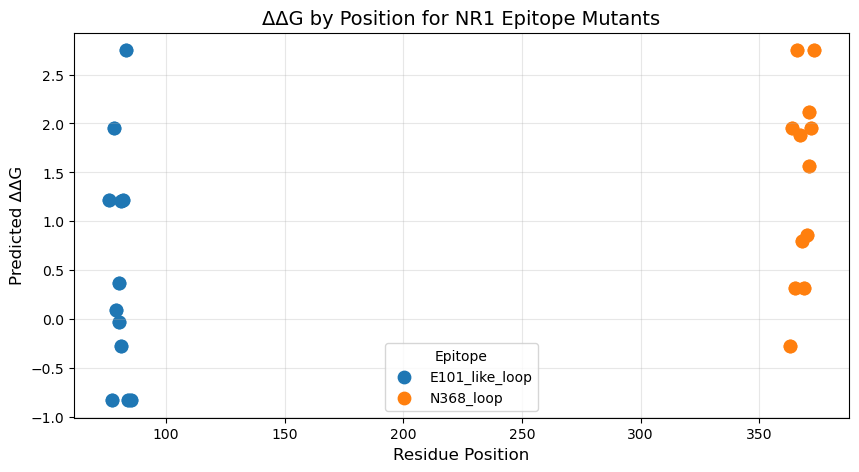

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# If not already loaded:
mutants_df = pd.read_csv("NR1_epitope_mutants_table.csv")

plt.figure(figsize=(10, 5))

for epitope, group in mutants_df.groupby("epitope_name"):
    plt.scatter(group["pos_index"], group["ddG_pred"],
                s=80, label=epitope)

plt.xlabel("Residue Position", fontsize=12)
plt.ylabel("Predicted ΔΔG", fontsize=12)
plt.title("ΔΔG by Position for NR1 Epitope Mutants", fontsize=14)
plt.legend(title="Epitope")
plt.grid(alpha=0.3)

plt.show()



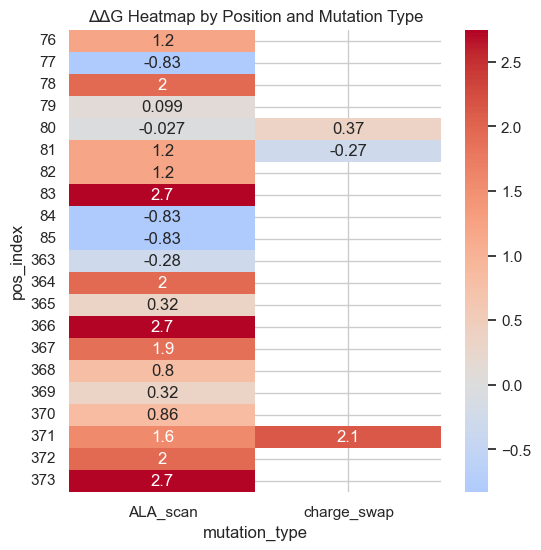

In [39]:
# Heat Map
import seaborn as sns
import matplotlib.pyplot as plt

pivot = mutants_df.pivot_table(
    index="pos_index",
    columns="mutation_type",
    values="ddG_pred"
)

plt.figure(figsize=(6,6))
sns.heatmap(pivot, annot=True, cmap="coolwarm", center=0)
plt.title("ΔΔG Heatmap by Position and Mutation Type")
plt.show()

<!-- RESULTS SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Results
  </h2>
  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
  Predicted ΔΔG values ranged from –0.9 to +2.9 kcal/mol, showing that the two epitope regions differ noticeably in how sensitive they are to mutation. The E101 loop showed the broadest range, from slightly stabilizing to strongly destabilizing changes. Several residues landed in the +1 to +2 kcal/mol range, and a few exceeded +2 kcal/mol, suggesting that some positions in this loop play a bigger role in maintaining local structure than others.
<p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
The N368 loop showed a tighter but consistently positive set of ΔΔG values, mostly between 0 and +2.8 kcal/mol. This pattern fits with what is known about the loop’s structural role around the N368 glycosylation site—mutations here tend to disrupt stability rather than improve it. As expected, charge-swapping mutations produced the largest ΔΔG shifts in both regions, while alanine substitutions resulted in a wider spread of effects. </p>
<p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
When ΔΔG values were plotted along the sequence, the two epitope windows formed clear clusters. Both clusters included several high-ΔΔG positions, and neither region appeared mutation-tolerant across the board. Overall, the patterns point to localized energetic sensitivity within each loop, which is consistent with how functional epitope surfaces typically behave.
  </p>
  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">

<!-- ANALYSIS SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Analysis
  </h2>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    The ΔΔG patterns across both loops point toward a shared theme: neither region behaves like a flexible, unimportant surface. Instead, both show signs of local structural constraint, which is exactly what would be expected for functional antibody epitopes on the NR1 ATD. In other words, these loops are not just loose decorations on the protein surface. They appear to contribute to how the ATD is shaped and stabilized.</p>
<p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
The N368 loop stands out because nearly every mutation increases ΔΔG to some degree. This consistent destabilization fits well with its known biological role. The N368 site carries an N-linked glycan, and multiple studies have shown that this glycan helps stabilize the ATD fold and influences antibody binding. Seeing uniformly positive ΔΔG values here suggests that even small changes disrupt the local environment, reinforcing the idea that this region is structurally important and not particularly tolerant of mutation. That kind of intolerance tends to show up in true epitope surfaces, where antibodies recognize a well-defined conformation rather than a floppy loop.</p>
<p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
The E101-like loop shows a more mixed pattern, which is interesting in a different way. Some positions tolerate alanine pretty well, while others produce strong destabilizing effects. This combination of some flexible spots paired with a few ridgid residues is common in exposed loops that participate in ligand or antibody interactions. A loop like this often has one or two anchor residues that help hold it in place, while the rest can shift or adapt slightly without collapsing the fold. The energetic sensitivity at specific positions supports the notion that this loop forms part of a structured, antibody-accessible patch on the ATD.</p>
<p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
It’s also worth noting that charge swaps tend to be the most disruptive in both regions. This makes sense because many antibody epitopes rely on precise side-chain interactions and electrostatic complementarity. Changing the charge often changes the local surface chemistry enough to distort the native conformation, especially in areas that help define the ATD’s overall shape.</p>
<p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
Taken together, the ΔΔG behavior across these two loops supports their interpretation as energetically meaningful, conformationally defined surfaces rather than flexible or low-importance segments. This matches what has been shown experimentally: antibodies targeting NR1 often rely on stable loop geometries within the ATD, including the regions around E101 and N368. The predicted energetic sensitivity adds another layer of evidence that these loops are likely to be authentic, ligandable epitope sites on NR1.
  </p>

<!-- REFERENCES SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    References
  </h2>

  <!-- SECTION 1 -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Literature:
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    Castillo-Gómez, E., Oliveira, B., Tapken, D., Bertrand, S., Klein-Schmidt, C., Pan, H., Zafeiriou, P., Steiner, J., Jurek, B., Trippe, R., Prüss, H., Zimmermann, W., Bertrand, D., Ehrenreich, H., & Hollmann, M. (2016). All naturally occurring autoantibodies against the NMDA receptor subunit NR1 have pathogenic potential irrespective of epitope and immunoglobulin class. Molecular Psychiatry, 22(12), 1776–1784. https://doi.org/10.1038/mp.2016.125<br><br>
      Tajima, N., Simorowski, N., Yovanno, R. A., Regan, M. C., Michalski, K., Gómez, R., Lau, A. Y., & Furukawa, H. (2022). Development and characterization of functional antibodies targeting NMDA receptors. Nature Communications, 13(1), 923. https://doi.org/10.1038/s41467-022-28559-3